In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm

In [3]:
smn_historico = pd.read_csv('../../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [4]:
cuyo = ["MENDOZA", "SAN JUAN", "SAN LUIS","LA RIOJA"]
smn_cuyo = smn_historico[smn_historico["provincia"].isin(cuyo)]
smn_cuyo

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
180,CHAMICAL AERO,LA RIOJA,461.0,87320.0,SACT,-30.333333,-66.283333,Ene,5.8,58.3,3.5,93.4,27.0,33.8,20.6,8.4
181,CHAMICAL AERO,LA RIOJA,461.0,87320.0,SACT,-30.333333,-66.283333,Feb,5.3,62.6,3.7,88.3,25.3,31.9,19.5,6.9
182,CHAMICAL AERO,LA RIOJA,461.0,87320.0,SACT,-30.333333,-66.283333,Mar,5.2,67.3,3.7,67.2,23.2,29.5,18.0,6.2
183,CHAMICAL AERO,LA RIOJA,461.0,87320.0,SACT,-30.333333,-66.283333,Abr,3.1,69.0,3.8,27.6,19.3,25.6,14.3,5.0
184,CHAMICAL AERO,LA RIOJA,461.0,87320.0,SACT,-30.333333,-66.283333,May,1.9,70.3,3.9,10.2,15.2,21.4,10.2,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Ago,2.4,63.3,3.4,15.6,9.7,20.2,1.5,11.2
1172,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Sep,4.0,60.9,3.6,35.4,13.1,22.6,4.6,12.6
1173,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Oct,7.1,63.0,3.9,65.8,16.9,25.2,8.9,16.3
1174,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Nov,8.8,62.0,3.8,92.4,20.0,28.1,11.9,15.1


In [5]:
smn_cuyo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 180 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      144 non-null    object 
 1   provincia     144 non-null    object 
 2   altura        144 non-null    float64
 3   numero        144 non-null    float64
 4   NroOACI       144 non-null    object 
 5   LAT_decimal   144 non-null    float64
 6   LON_decimal   144 non-null    float64
 7   mes_txt       144 non-null    object 
 8   prec_sup_1mm  139 non-null    float64
 9   humedad       143 non-null    float64
 10  nubosidad     144 non-null    float64
 11  prec_mm       139 non-null    float64
 12  temp          144 non-null    float64
 13  temp_max      144 non-null    float64
 14  temp_min      144 non-null    float64
 15  viento        72 non-null     float64
dtypes: float64(12), object(4)
memory usage: 19.1+ KB


In [6]:
#Verificacion
smn_cuyo["provincia"].unique()


array(['LA RIOJA', 'SAN JUAN', 'MENDOZA', 'SAN LUIS'], dtype=object)

In [7]:
#Cantidad de estaciones
smn_cuyo["estacion"].nunique()

12

In [8]:
#Alutra media
smn_cuyo["altura"].mean()

763.8333333333334

In [9]:
#Temperatura Media
smn_cuyo["temp"].mean()

17.063194444444445

In [10]:
#Temperatura dev std
smn_cuyo["temp"].std()

6.295994359028602

In [11]:
#Precipitacion media
smn_cuyo["prec_mm"].mean()

28.64748201438849

In [12]:
#Mes en temperatura media mas alta
month_group = smn_cuyo.groupby("mes_txt")
month_max_avg_temp = month_group["temp"].mean() == month_group["temp"].mean().max()
month_max_avg_temp

mes_txt
Abr    False
Ago    False
Dic    False
Ene     True
Feb    False
Jul    False
Jun    False
Mar    False
May    False
Nov    False
Oct    False
Sep    False
Name: temp, dtype: bool

In [13]:
#Mes en precipitacion medias mas alta
month_max_avg_hum = month_group["prec_mm"].mean() == month_group["prec_mm"].mean().max()
month_max_avg_hum

mes_txt
Abr    False
Ago    False
Dic    False
Ene     True
Feb    False
Jul    False
Jun    False
Mar    False
May    False
Nov    False
Oct    False
Sep    False
Name: prec_mm, dtype: bool

In [14]:
#Provinicia con mayor temperatura media
provincia_group = smn_cuyo.groupby("provincia")
temp_provincias = provincia_group["temp"].mean()
temp_provincias

provincia
LA RIOJA    19.577778
MENDOZA     15.586667
SAN JUAN    17.395833
SAN LUIS    16.650000
Name: temp, dtype: float64

temp          Axes(0.125,0.11;0.352273x0.77)
prec_mm    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

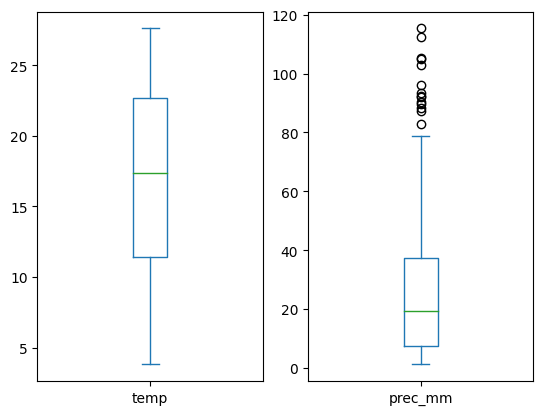

In [15]:
smn_cuyo[["temp","prec_mm"]].plot(kind="box",subplots=True)

In [16]:
Q1 = smn_cuyo.quantile(0.25, numeric_only=True)
Q3 = smn_cuyo.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

smn_cuyo_numeric = smn_cuyo.select_dtypes(include="number")
outlier_condition = (smn_cuyo_numeric < lower_bound) | (smn_cuyo_numeric > upper_bound)
total_outliers = outlier_condition.sum()
total_outliers[["temp","prec_mm"]]

temp        0
prec_mm    14
dtype: int64

In [17]:
san_luis = smn_historico[smn_historico["provincia"] == "SAN LUIS"]
san_luis

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
948,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Ene,8.3,52.9,3.5,115.3,24.8,31.6,18.3,17.4
949,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Feb,7.0,58.1,3.3,112.5,23.2,30.0,17.2,15.9
950,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Mar,6.8,62.7,3.2,92.1,21.1,27.6,15.5,14.5
951,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Abr,4.4,64.9,3.5,44.8,16.9,23.3,11.8,13.6
952,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,May,2.6,66.2,4.0,18.6,13.2,19.6,8.3,12.1
953,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Jun,1.2,62.0,3.7,5.4,10.3,17.1,5.0,13.4
954,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Jul,1.4,56.1,3.4,5.4,9.6,16.7,4.0,13.9
955,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Ago,1.6,47.6,3.1,8.6,12.2,19.5,6.2,15.6
956,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Sep,2.8,45.5,3.3,22.0,15.3,22.4,9.1,16.5
957,SAN LUIS AERO,SAN LUIS,713.0,87436.0,SAOU,-33.266667,-66.350000,Oct,5.0,47.8,3.5,50.1,18.9,25.6,12.5,18.4


In [18]:
san_luis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 948 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      24 non-null     object 
 1   provincia     24 non-null     object 
 2   altura        24 non-null     float64
 3   numero        24 non-null     float64
 4   NroOACI       24 non-null     object 
 5   LAT_decimal   24 non-null     float64
 6   LON_decimal   24 non-null     float64
 7   mes_txt       24 non-null     object 
 8   prec_sup_1mm  24 non-null     float64
 9   humedad       24 non-null     float64
 10  nubosidad     24 non-null     float64
 11  prec_mm       24 non-null     float64
 12  temp          24 non-null     float64
 13  temp_max      24 non-null     float64
 14  temp_min      24 non-null     float64
 15  viento        24 non-null     float64
dtypes: float64(12), object(4)
memory usage: 3.2+ KB


In [19]:
#Cantidad de staciones
san_luis["estacion"].unique()

array(['SAN LUIS AERO', 'VILLA REYNOLDS AERO'], dtype=object)

In [20]:
san_luis[["humedad","prec_mm","temp","viento"]].describe()

,humedad,prec_mm,temp,viento
count,24.000000,24.000000,24.000000,24.000000
mean,61.937500,57.975000,16.650000,13.458333
std,9.673847,40.220147,5.590909,3.293857
min,45.500000,5.400000,7.000000,7.800000
25%,55.300000,17.850000,12.000000,11.150000
50%,62.400000,57.950000,16.900000,13.750000
75%,67.875000,93.350000,21.650000,16.000000
max,77.400000,115.300000,24.800000,18.400000


In [21]:
meses_orden = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", 
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
san_luis["mes_txt"] = pd.Categorical(san_luis["mes_txt"], categories=meses_orden, ordered=True)
san_luis_month = san_luis.groupby("mes_txt")
san_luis_numerics_mean = san_luis_month.mean(numeric_only=True).drop(columns=["altura","numero","LAT_decimal","LON_decimal","temp_max","temp_min","prec_sup_1mm", "nubosidad", "viento"])
san_luis_numerics_mean

/tmp/ipykernel_34843/527845265.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  san_luis["mes_txt"] = pd.Categorical(san_luis["mes_txt"], categories=meses_orden, ordered=True)
/tmp/ipykernel_34843/527845265.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  san_luis_month = san_luis.groupby("mes_txt")


,humedad,prec_mm,temp
mes_txt,,,
Ene,59.90,109.05,24.05
Feb,65.10,101.15,22.40
Mar,68.90,94.15,20.30
Abr,70.40,56.85,16.10
May,71.80,25.15,12.30
Jun,68.50,7.60,9.15
Jul,63.45,7.95,8.30
Ago,55.45,12.10,10.95
Sep,53.20,28.70,14.20


In [22]:
san_luis_numerics_mean.mean()

humedad    61.9375
prec_mm    57.9750
temp       16.6500
dtype: float64

array([<Axes: xlabel='mes_txt'>, <Axes: xlabel='mes_txt'>,
       <Axes: xlabel='mes_txt'>], dtype=object)

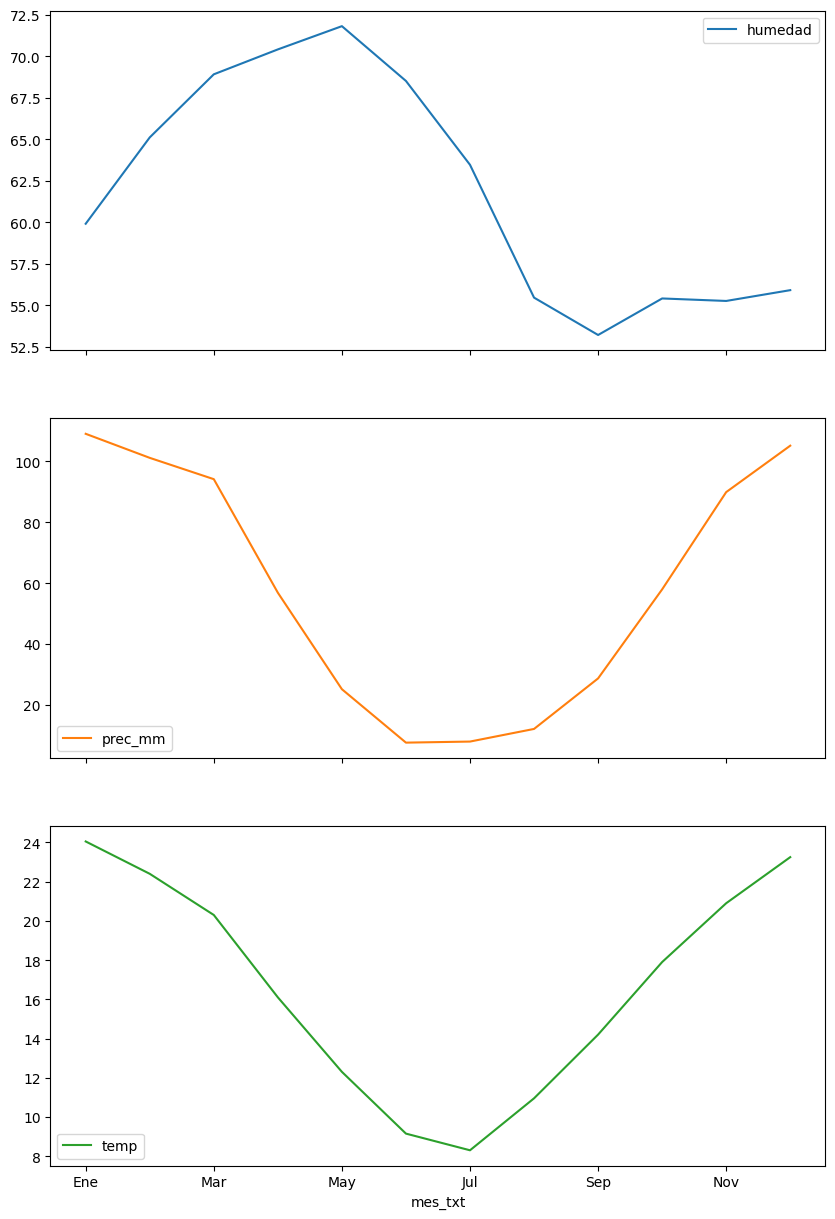

In [23]:
san_luis_numerics_mean.plot(kind="line",subplots=True,figsize=(10,15))

humedad       Axes(0.125,0.11;0.227941x0.77)
prec_mm    Axes(0.398529,0.11;0.227941x0.77)
temp       Axes(0.672059,0.11;0.227941x0.77)
dtype: object

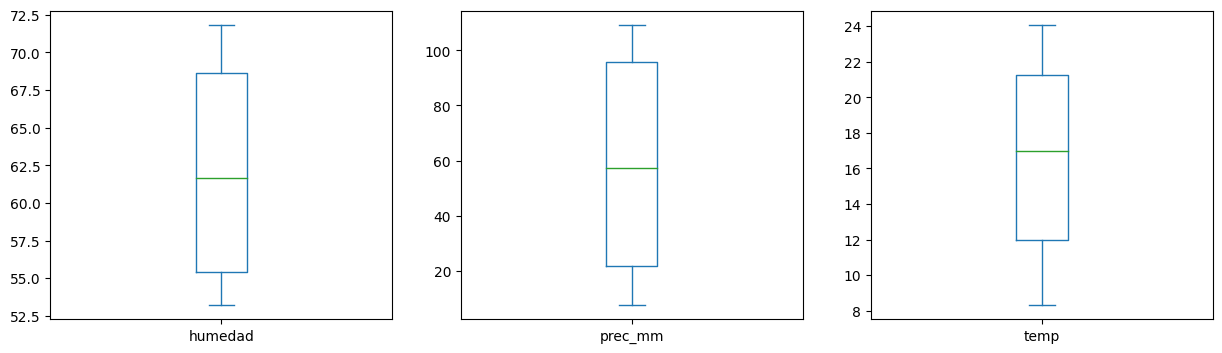

In [24]:
san_luis_numerics_mean.plot(kind="box",subplots=True,figsize=(15,4))

In [25]:
smn_historico.groupby("provincia")["viento"].mean()

provincia
ANTARTIDA          21.658333
BUENOS AIRES       13.040625
CAPITAL FEDERAL    11.679167
CATAMARCA          18.175000
CHACO                    NaN
CHUBUT             17.752778
CORDOBA            10.765278
CORRIENTES         13.458333
ENTRE RIOS         11.700000
FORMOSA             9.012500
JUJUY               6.761111
LA PAMPA           14.733333
LA RIOJA            6.833333
MENDOZA            10.504167
MISIONES            9.987500
NEUQUEN             9.750000
RIO NEGRO          12.986111
SALTA               7.554167
SAN JUAN           13.325000
SAN LUIS           13.458333
SANTA CRUZ         23.183333
SANTA FE           12.544444
SANTIAGO DEL ES     8.716667
TIERRA DEL FUEG    23.137500
TUCUMAN             8.716667
Name: viento, dtype: float64

In [26]:
smn_historico_san_luis = smn_historico[smn_historico["estacion"] == "SAN LUIS AERO"]
smn_historico_san_luis.mean(numeric_only=True)

altura            713.000000
numero          87436.000000
LAT_decimal       -33.266667
LON_decimal       -66.350000
prec_sup_1mm        4.700000
humedad            55.166667
nubosidad           3.433333
prec_mm            55.591667
temp               17.608333
temp_max           24.391667
temp_min           11.691667
viento             15.608333
dtype: float64

/tmp/ipykernel_34843/23713306.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df["mes_txt"] = pd.Categorical(temp_df["mes_txt"], categories=meses_orden, ordered=True)
/tmp/ipykernel_34843/23713306.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df_month = temp_df.groupby("mes_txt")


array([<Axes: xlabel='mes_txt'>, <Axes: xlabel='mes_txt'>,
       <Axes: xlabel='mes_txt'>], dtype=object)

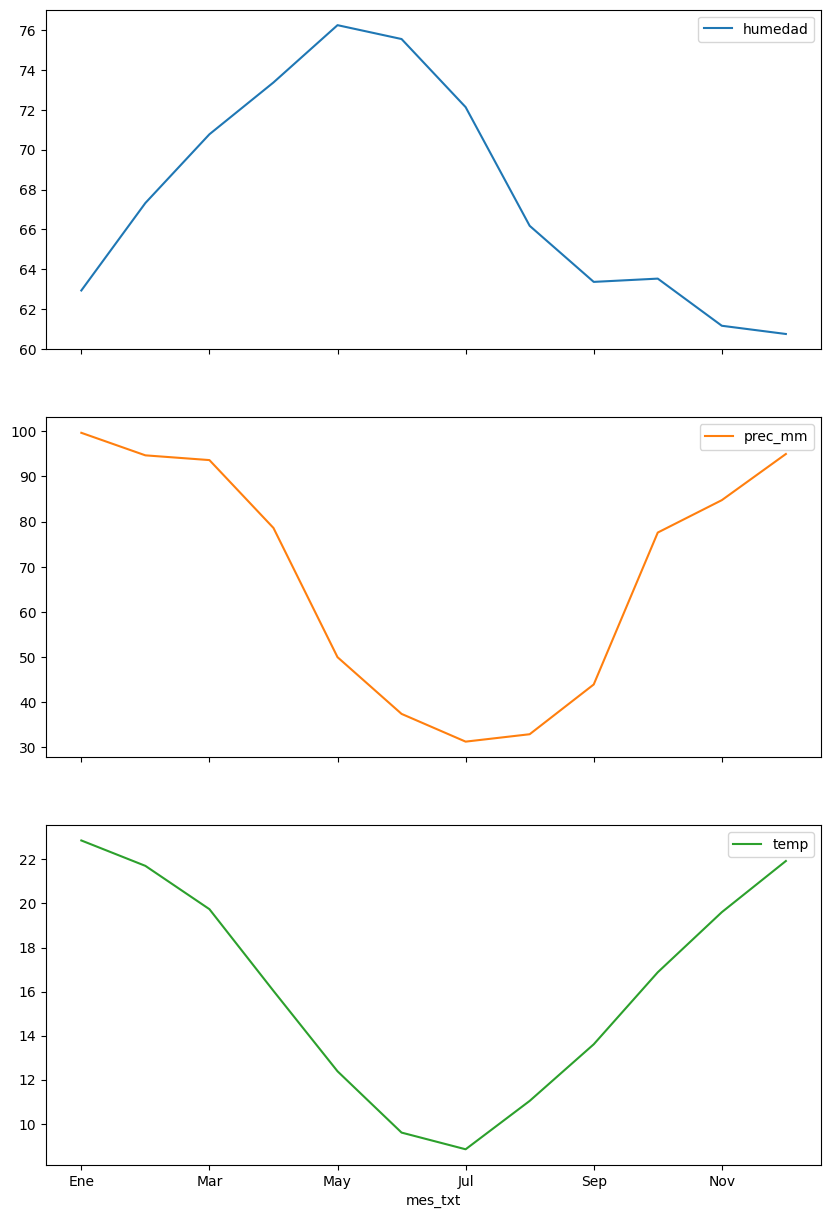

In [34]:
temp_df = smn_historico[smn_historico['provincia'] != 'ANTARTIDA']
temp_df["mes_txt"] = pd.Categorical(temp_df["mes_txt"], categories=meses_orden, ordered=True)
temp_df_month = temp_df.groupby("mes_txt")
temp_df_numerics_mean = temp_df_month.mean(numeric_only=True).drop(columns=["altura","numero","LAT_decimal","LON_decimal","temp_max","temp_min","prec_sup_1mm", "nubosidad", "viento"])
temp_df_numerics_mean.plot(kind="line",subplots=True,figsize=(10,15))

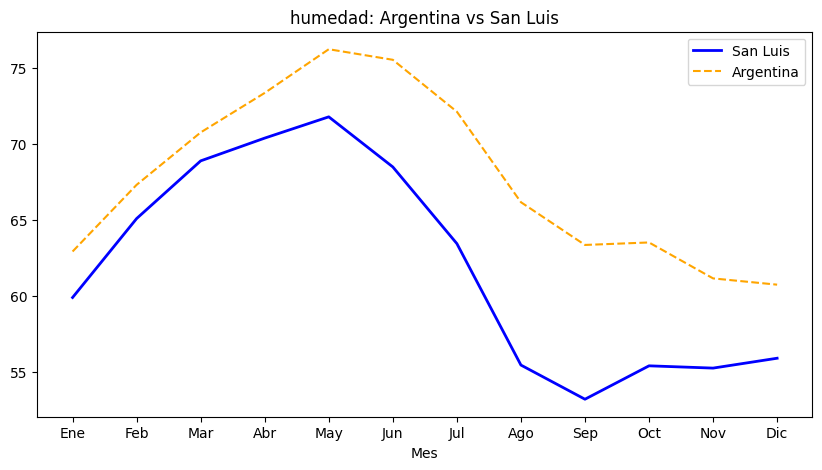

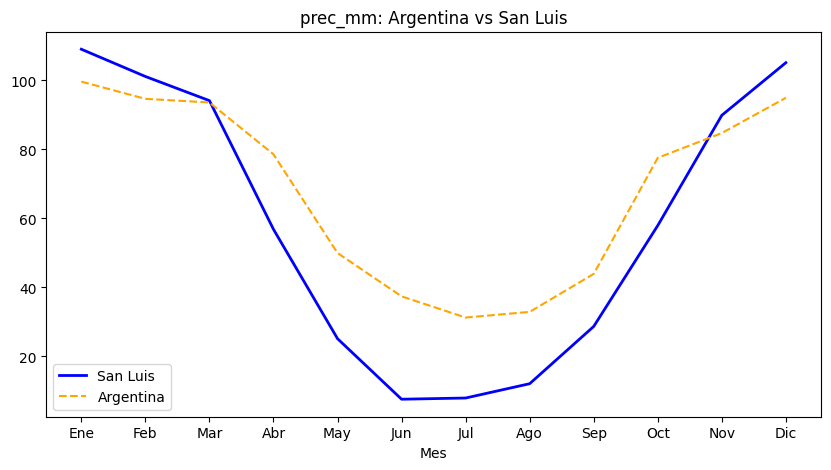

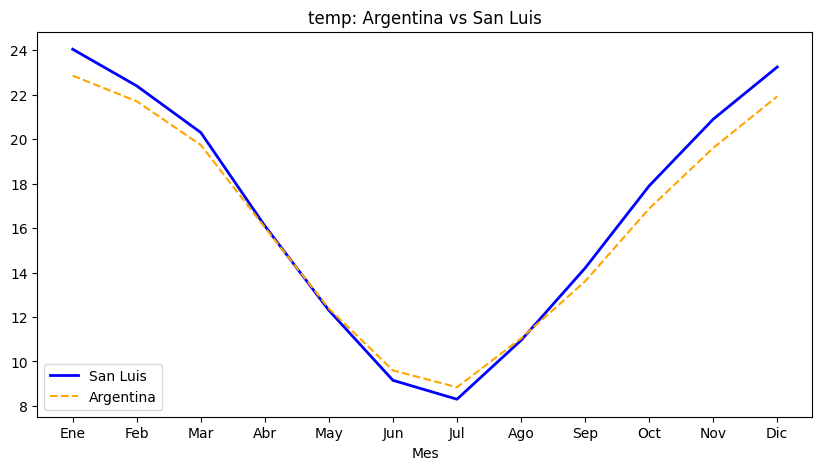

In [35]:
for col in temp_df_numerics_mean.columns:
    plt.figure(figsize=(10, 5))    
    plt.plot(san_luis_numerics_mean.index, san_luis_numerics_mean[col], label='San Luis', color='blue', linewidth=2)
    plt.plot(temp_df_numerics_mean.index, temp_df_numerics_mean[col], label='Argentina', color='orange', linestyle='--')
    plt.title(f'{col}: Argentina vs San Luis')
    plt.xlabel('Mes')
    plt.legend()
    plt.show()

In [36]:
max_san_luis, min_san_luis = san_luis_numerics_mean["temp"].max(), san_luis_numerics_mean["temp"].min()
print(f"Maxima San Luis: {max_san_luis}, minima San Luis: {min_san_luis}. Brecha: {max_san_luis-min_san_luis}")

Maxima San Luis: 24.05, minima San Luis: 8.3. Brecha: 15.75


In [37]:
max_argentina, min_argentina = temp_df_numerics_mean["temp"].max(), temp_df_numerics_mean["temp"].min()
print(f"Maxima Argentina: {max_argentina}, minima Argentina: {min_argentina}. Brecha: {max_argentina-min_argentina}")

Maxima Argentina: 22.86111111111111, minima Argentina: 8.840449438202247. Brecha: 14.020661672908863


In [48]:
temp_df[["provincia","estacion","viento"]].groupby("estacion").mean(numeric_only=True).sort_values("viento",ascending=False).head(20)


,viento
estacion,
PERITO MORENO AERO,26.916667
SAN JULIAN AERO,25.883333
RIO GRANDE B.A.,23.608333
USHUAIA AERO,22.666667
RIO GALLEGOS AERO,22.375000
COMODORO RIVADAVIA AERO,20.266667
BARILOCHE AERO,19.550000
BAHIA BLANCA AERO,18.225000
CATAMARCA AERO,18.175000
